# 05 - HOG + RGB Histogram + SVM Pipeline

### Import các thư viện cần thiết cho quá trình:
- Xử lý ảnh
- Trích xuất đặc trưng HOG + RGB Histogram
- Huấn luyện và đánh giá mô hình SVM
- Trực quan hóa kết quả

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from concurrent.futures import (
    ThreadPoolExecutor,
    as_completed
)

import joblib
from joblib import parallel_backend

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



## Cấu hình dữ liệu và kích thước ảnh

Thiết lập:
- Kích thước chuẩn cho ảnh đầu vào
- Đường dẫn tập train và test

In [7]:
IMAGE_SIZE = (128, 128)
TRAIN_DIR = '../data/raw/seg_train'
TEST_DIR = '../data/raw/seg_test'
FEATURE_OUTPUT_DIR = '../outputs/features/cs114'
MODEL_PATH = "../models/cs114/best_hog_rgb_svm.pkl"

## Tiền xử lý và tải dữ liệu

Cell này:
- Đọc ảnh từ thư mục dataset
- Resize ảnh về cùng kích thước
- Chuyển đổi màu từ BGR sang RGB
- Tăng tốc tải dữ liệu bằng đa luồng

In [18]:
def read_image(args):

    img_path, label = args

    img = cv2.imread(img_path)

    if img is None:
        return None

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    img = cv2.resize(
        img,
        IMAGE_SIZE
    )

    return img, label

def load_data_fast(data_dir, max_workers=8):

    image_paths = []
    classes = []

    for i, label_name in enumerate(sorted(os.listdir(data_dir))):

        label_dir = os.path.join(data_dir, label_name)

        if not os.path.isdir(label_dir):
            continue

        classes.append(label_name)

        for file_name in os.listdir(label_dir):

            img_path = os.path.join(
                label_dir,
                file_name
            )

            image_paths.append((img_path, i))

    with ThreadPoolExecutor(max_workers=max_workers) as executor:

        results = list(
            executor.map(
                read_image,
                image_paths
            )
        )

    results = [
        r for r in results
        if r is not None
    ]

    images = [r[0] for r in results]
    labels = [r[1] for r in results]

    return (
        np.array(images),
        np.array(labels),
        classes
    )

## Trích xuất đặc trưng HOG và RGB Histogram

Bao gồm:
- HOG: mô tả thông tin hình dạng, cạnh và texture
- RGB Histogram: mô tả phân bố màu sắc

Hai loại đặc trưng sẽ được kết hợp để tạo vector đặc trưng cuối cùng.

In [19]:
def extract_hog_features(
    images,
    orientations,
    pixels_per_cell,
    cells_per_block
):

    features = []
    for img in images:
        gray = cv2.cvtColor(
            img,
            cv2.COLOR_RGB2GRAY
        )
        hog_feature = hog(
            gray,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm='L2-Hys'
        )
        features.append(hog_feature)
    return np.array(features)

def extract_rgb_histogram(
    images,
    bins
):
    features = []
    for img in images:
        hist = cv2.calcHist(
            [img],
            [0,1,2],
            None,
            bins,
            [0,256,0,256,0,256]
        )
        hist = cv2.normalize(
            hist,
            hist
        ).flatten()
        features.append(hist)
    return np.array(features)

## Hàm thực hiện một lần thử nghiệm đặc trưng

Quy trình:
1. Trích xuất đặc trưng HOG
2. Trích xuất RGB Histogram
3. Kết hợp đặc trưng
4. Huấn luyện SVM
5. Đánh giá trên tập validation bằng Accuracy

In [ ]:
def run_experiment(
    hog_config,
    rgb_bins,
    X_tune,
    X_val,
    y_tune,
    y_val
):
    print("\n================================")
    print("Testing:")
    print("HOG:", hog_config)
    print("RGB:", rgb_bins)
    # -----------------------------
    # HOG
    # -----------------------------

    X_train_hog = extract_hog_features(
        X_tune,
        orientations=hog_config['orientations'],
        pixels_per_cell=hog_config['pixels_per_cell'],
        cells_per_block=hog_config['cells_per_block']
    )

    X_val_hog = extract_hog_features(
        X_val,
        orientations=hog_config['orientations'],
        pixels_per_cell=hog_config['pixels_per_cell'],
        cells_per_block=hog_config['cells_per_block']
    )

    # -----------------------------
    # RGB
    # -----------------------------
    X_train_rgb = extract_rgb_histogram(
        X_tune,
        bins=rgb_bins
    )

    X_val_rgb = extract_rgb_histogram(
        X_val,
        bins=rgb_bins
    )

    # -----------------------------
    # CONCATENATE
    # -----------------------------
    X_train_final = np.concatenate(
        [X_train_hog, X_train_rgb],
        axis=1
    )

    X_test_final = np.concatenate(
        [X_val_hog, X_val_rgb],
        axis=1
    )

    # -----------------------------
    # MODEL
    # -----------------------------
    model = SVC()

    model.fit(
        X_train_final,
        y_tune
    )

    y_pred = model.predict(
        X_test_final
    )

    acc = accuracy_score(
        y_val,
        y_pred
    )

    print(f"Accuracy: {acc:.4f}")

    return {
        'hog': hog_config,
        'rgb_bins': rgb_bins,
        'accuracy': acc
    }

# =========================================================
# MULTITHREAD FEATURE TUNING
# =========================================================

def tune_features_multithread(
    hog_params,
    rgb_bins_list,
    X_tune,
    X_val,
    y_tune,
    y_val,
    max_workers=8,
):
    futures = []
    results = []
    best_acc = 0
    best_hog = None
    best_rgb = None

    with ThreadPoolExecutor(
        max_workers=max_workers
    ) as executor:
        for hog_config in hog_params:
            for rgb_bins in rgb_bins_list:
                future = executor.submit(
                    run_experiment,
                    hog_config,
                    rgb_bins,
                    X_tune, X_val, y_tune, y_val
                )
                futures.append(future)

        for future in as_completed(futures):
            result = future.result()
            results.append(result)

            if result['accuracy'] > best_acc:
                best_acc = result['accuracy']
                best_hog = result['hog']
                best_rgb = result['rgb_bins']

    print("\n================================")
    print("BEST FEATURE CONFIG")
    print("Accuracy:", best_acc)
    print("\nBest HOG:")
    print(best_hog)
    print("\nBest RGB:")
    print(best_rgb)
    return results, best_hog, best_rgb

# Khởi tạo tập tham số thử nghiệm

Bao gồm:
- Các cấu hình HOG khác nhau
- Các số lượng bins cho RGB Histogram

Mục tiêu:
Tìm ra bộ đặc trưng cho kết quả tốt nhất trên tập validation.

In [7]:

# =========================================================
# PARAMETER SPACE
# =========================================================

hog_params = [

    {
        'orientations': 9,
        'pixels_per_cell': (8,8),
        'cells_per_block': (2,2)
    },

    {
        'orientations': 12,
        'pixels_per_cell': (8,8),
        'cells_per_block': (2,2)
    },

    {
        'orientations': 16,
        'pixels_per_cell': (8,8),
        'cells_per_block': (2,2)
    },

    {
        'orientations': 9,
        'pixels_per_cell': (4,4),
        'cells_per_block': (2,2)
    }
]

rgb_bins_list = [
    (8,8,8),
    (16,16,16),
    (32,32,32)
]

## Load dataset và chia train/validation

Dữ liệu được chia thành:
- Train set
- Validation set
- Test set

Validation set được dùng để:
- So sánh các bộ đặc trưng
- Tối ưu tham số SVM

In [20]:
# =========================================================
# LOAD DATA
# =========================================================

X, y, classes = load_data_fast(
    TRAIN_DIR,
    max_workers=12
)
X_test, y_test, classes = load_data_fast(
    TEST_DIR,
    max_workers=12
)
# =========================================================
# SPLIT
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [6]:
print("Train shape: ", X_train.shape)
print("Val shape:", X_val.shape)
print("Test shape: ", X_test.shape)

Train shape:  (11229, 128, 128, 3)
Val shape: (2808, 128, 128, 3)
Test shape:  (3000, 128, 128, 3)


### Sử dụng 20% tập train để tuning

Mục đích:
- Giảm thời gian huấn luyện
- Vẫn giữ tính đại diện dữ liệu bằng stratified split

In [ ]:
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.2,
    stratify=y_train,
    random_state=42
)

## Tối ưu đặc trưng HOG + RGB

Thực hiện:
- Thử nhiều cấu hình HOG
- Thử nhiều RGB bins
- Huấn luyện và đánh giá bằng Accuracy trên validation set

Kết quả:
Chọn bộ đặc trưng tốt nhất.

In [ ]:
results, best_hog, best_rgb = tune_features_multithread(
    hog_params,
    rgb_bins_list,
    X_tune, X_val, y_tune, y_val,
    max_workers=4
)


Testing:
HOG: {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (8, 8, 8)

Testing:
HOG: {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (16, 16, 16)

Testing:
HOG: {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (32, 32, 32)

Testing:
HOG: {'orientations': 12, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (8, 8, 8)
Accuracy: 0.7378

Testing:
HOG: {'orientations': 12, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (16, 16, 16)
Accuracy: 0.7328

Testing:
HOG: {'orientations': 12, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (32, 32, 32)
Accuracy: 0.7417

Testing:
HOG: {'orientations': 16, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (8, 8, 8)
Accuracy: 0.7307

Testing:
HOG: {'orientations': 16, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}
RGB: (16, 16, 16)
Accuracy: 0.7360

Testing:
HOG: {'orientations': 16, 'pixels_per_cell': (8, 8), 

## Tổng hợp kết quả thử nghiệm
Chuyển toàn bộ kết quả tuning thành DataFrame để:
- Dễ quan sát
- Dễ phân tích
- Chuẩn bị trực quan hóa

In [ ]:
results_df = pd.DataFrame(results)
print(results_df)

                                                  hog      rgb_bins  accuracy
0   {'orientations': 9, 'pixels_per_cell': (8, 8),...     (8, 8, 8)  0.737798
1   {'orientations': 9, 'pixels_per_cell': (8, 8),...  (16, 16, 16)  0.732811
2   {'orientations': 12, 'pixels_per_cell': (8, 8)...     (8, 8, 8)  0.741717
3   {'orientations': 9, 'pixels_per_cell': (8, 8),...  (32, 32, 32)  0.730673
4   {'orientations': 12, 'pixels_per_cell': (8, 8)...  (16, 16, 16)  0.736017
5   {'orientations': 16, 'pixels_per_cell': (8, 8)...     (8, 8, 8)  0.733880
6   {'orientations': 12, 'pixels_per_cell': (8, 8)...  (32, 32, 32)  0.726755
7   {'orientations': 16, 'pixels_per_cell': (8, 8)...  (16, 16, 16)  0.728180
8   {'orientations': 16, 'pixels_per_cell': (8, 8)...  (32, 32, 32)  0.726042
9   {'orientations': 9, 'pixels_per_cell': (4, 4),...     (8, 8, 8)  0.497684
10  {'orientations': 9, 'pixels_per_cell': (4, 4),...  (16, 16, 16)  0.496972
11  {'orientations': 9, 'pixels_per_cell': (4, 4),...  (32, 32, 

## Biểu đồ Accuracy của các cấu hình đặc trưng

Biểu đồ cột thể hiện:
- Accuracy của từng bộ tham số
- So sánh hiệu quả giữa các cấu hình HOG + RGB

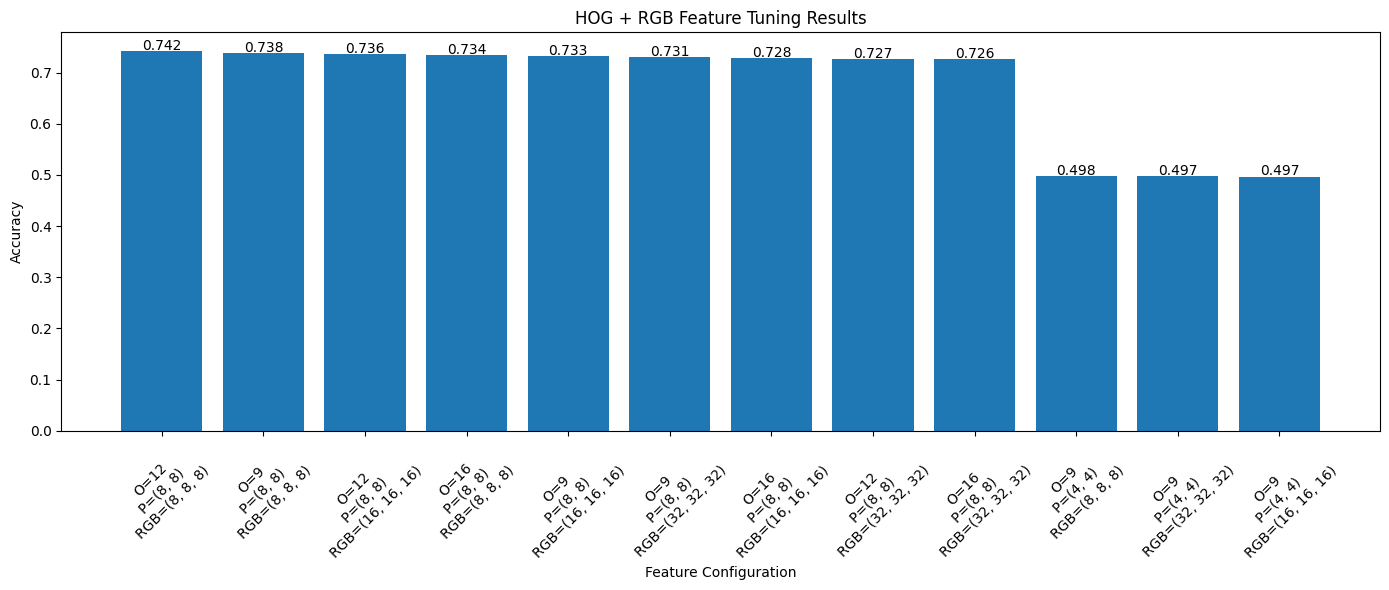

In [ ]:
results_df['label'] = results_df.apply(
    lambda row:
    f"O={row['hog']['orientations']}\n"
    f"P={row['hog']['pixels_per_cell']}\n"
    f"RGB={row['rgb_bins']}",
    axis=1
)
results_df = results_df.sort_values(
    by='accuracy',
    ascending=False
)
plt.figure(figsize=(14,6))
plt.bar(
    results_df['label'],
    results_df['accuracy']
)
plt.xticks(rotation=45)
plt.ylabel("Accuracy")
plt.xlabel("Feature Configuration")
plt.title(
    "HOG + RGB Feature Tuning Results"
)

for i, score in enumerate(results_df['accuracy']):

    plt.text(
        i,
        score + 0.002,
        f"{score:.3f}",
        ha='center'
    )

plt.tight_layout()

plt.show()

## Lưu bộ đặc trưng tốt nhất

Lưu:
- HOG parameters
- RGB Histogram parameters

Dùng cho bước tối ưu SVM phía sau.

In [ ]:
import json

# =========================================
# Save best feature parameters
# =========================================

best_feature_params = {

    'hog': {
        'orientations':
            best_hog['orientations'],
        'pixels_per_cell':
            best_hog['pixels_per_cell'],
        'cells_per_block':
            best_hog['cells_per_block']
    },

    'rgb': {
        'bins': best_rgb
    },
}

# =========================================
# Save to JSON
# =========================================

with open(
    'best_feature_params.json',
    'w'
) as f:
    json.dump(
        best_feature_params,
        f,
        indent=4
    )

print("Best feature parameters saved.")

Best feature parameters saved.


# Pipeline huấn luyện mô hình

Pipeline gồm:
1. Load tham số đặc trưng tốt nhất
2. Trích xuất đặc trưng
3. Tối ưu SVM
4. Huấn luyện trên toàn bộ train set
5. Đánh giá trên test set

## Đọc tham số đặc trưng tốt nhất

Load file JSON chứa:
- HOG parameters
- RGB Histogram parameters

In [ ]:
with open(
    'best_feature_params.json',
    'r'
) as f:

    best_feature_params = json.load(f)

# Khởi tạo cấu hình đặc trưng

Tách các tham số:
- orientations
- pixels_per_cell
- cells_per_block
- RGB bins

để sử dụng cho pipeline trích xuất đặc trưng.

In [ ]:

# -------------------------
# HOG params
# -------------------------
hog_cfg = best_feature_params['hog']
orientations = hog_cfg['orientations']
pixels_per_cell = tuple(
    hog_cfg['pixels_per_cell']
)
cells_per_block = tuple(
    hog_cfg['cells_per_block']
)

# -------------------------
# RGB params
# -------------------------
rgb_bins = tuple(
    best_feature_params['rgb']['bins']
)
print(best_feature_params)

{'hog': {'orientations': 12, 'pixels_per_cell': [8, 8], 'cells_per_block': [2, 2]}, 'rgb': {'bins': [8, 8, 8]}}


## Kết hợp HOG + RGB Histogram

Cell này:
- Trích xuất HOG features
- Trích xuất RGB Histogram features
- Ghép thành vector đặc trưng cuối cùng

In [8]:

# =========================================================
# FEATURE PIPELINE
# =========================================================

def build_features(images):
    hog_features = extract_hog_features(images=images, orientations=12, pixels_per_cell=(8,8), cells_per_block=(2,2))
    rgb_features = extract_rgb_histogram(images, bins=(8,8,8))
    final_features = np.concatenate(
        [hog_features, rgb_features],
        axis=1
    )
    return final_features

## Xây dựng feature vector cho train và test

Kết quả:
- Feature matrix cho train set
- Feature matrix cho test set

In [9]:

# =========================================================
# BUILD FEATURES
# =========================================================

X_train_features = build_features(X_train)
X_test_features = build_features(X_test)
print("Train shape:", X_train_features.shape)
print("Test shape:", X_test_features.shape)

# =========================================================
# SAVE FEATURES TO NPZ
# =========================================================

np.savez_compressed(
    f"{FEATURE_OUTPUT_DIR}/intel_rgb_hog_features.npz",

    X_train_features=X_train_features,
    X_test_features=X_test_features,

    y_train=y_train,
    y_test=y_test,
    classes=classes
)

print("Features saved successfully!")

Train shape: (11229, 11312)
Test shape: (3000, 11312)
Features saved successfully!


## Lấy 20% dữ liệu để tối ưu SVM

Mục tiêu:
- Giảm thời gian GridSearch
- Vẫn đảm bảo tính đại diện dữ liệu

In [ ]:

# =========================================================
# TAKE 20% TRAIN FOR MODEL TUNING
# =========================================================
X_tune, _, y_tune, _ = train_test_split(
    X_train_features,
    y_train,
    train_size=0.2,
    stratify=y_train,
    random_state=42
)

## Tối ưu tham số SVM

Thử nghiệm nhiều:
- Kernel
- C
- Gamma
- Degree

Sử dụng GridSearchCV với độ đo Accuracy.

In [25]:
# =========================================
# Parameter grid
# Separate grids for different kernels
# =========================================

param_grid = [
    {
        'kernel': ['linear'],
        'C': [1, 5, 10, 50]
    },
    {
        'kernel': ['rbf'],
        'C': [1, 5, 10, 50],
        'gamma': ['scale', 0.01, 0.001]
    },

    {
        'kernel': ['poly'],
        'C': [1, 5, 10, 50],
        'gamma': ['scale', 0.01, 0.001],
        'degree': [2, 3]
    }
]

# =========================================
# Grid Search
# =========================================

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=2,
    scoring='accuracy',
    verbose=2,
    n_jobs=-1,
    return_train_score=True
)

# =========================================
# Train with multithreading
# =========================================
with parallel_backend('threading'):
    grid_search.fit(X_tune, y_tune)


Fitting 2 folds for each of 40 candidates, totalling 80 fits
[CV] END ................................C=10, kernel=linear; total time=32.5min
[CV] END .................................C=5, kernel=linear; total time=32.6min
[CV] END .................................C=5, kernel=linear; total time=33.2min
[CV] END .................................C=1, kernel=linear; total time=33.2min
[CV] END ................................C=50, kernel=linear; total time=33.3min
[CV] END .................................C=1, kernel=linear; total time=33.3min
[CV] END ................................C=10, kernel=linear; total time=34.0min
[CV] END ................................C=50, kernel=linear; total time=34.1min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=38.5min
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=38.7min
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=38.8min
[CV] END .......................C=1, gamma=scale

## Phân tích kết quả GridSearch

Thực hiện:
- Chuyển kết quả thành DataFrame
- Lấy top cấu hình tốt nhất cho từng kernel
- So sánh hiệu năng giữa các kernel

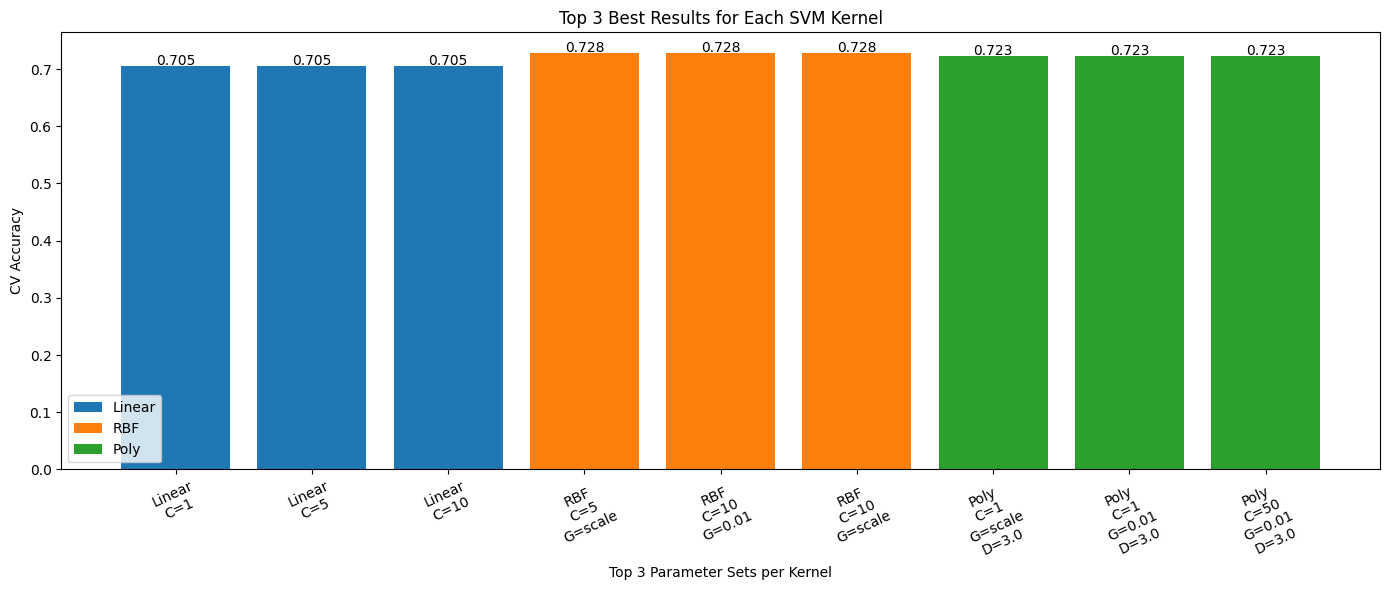

In [35]:
# =========================================
# Convert results to DataFrame
# =========================================
results = pd.DataFrame(grid_search.cv_results_)

# =========================================
# Collect top 3 for each kernel
# =========================================
top_results = []
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    kernel_df = results[
        results['param_kernel'] == kernel
    ].copy()
    kernel_df = kernel_df.sort_values(
        by='mean_test_score',
        ascending=False
    ).head(3)
    top_results.append(kernel_df)
# merge all
top_results = pd.concat(top_results).reset_index(drop=True)

# =========================================
# Create labels
# =========================================
labels = []
for _, row in top_results.iterrows():
    kernel = row['param_kernel']

    if kernel == 'linear':
        label = (
            f"Linear\n"
            f"C={row['param_C']}"
        )
    elif kernel == 'rbf':
        label = (
            f"RBF\n"
            f"C={row['param_C']}\n"
            f"G={row['param_gamma']}"
        )
    else:
        label = (
            f"Poly\n"
            f"C={row['param_C']}\n"
            f"G={row['param_gamma']}\n"
            f"D={row['param_degree']}"
        )
    labels.append(label)
top_results['label'] = labels

# =========================================
# Assign colors by kernel
# =========================================
color_map = {
    'linear': 'tab:blue',
    'rbf': 'tab:orange',
    'poly': 'tab:green'
}
colors = [
    color_map[k]
    for k in top_results['param_kernel']
]

# =========================================
# Plot
# =========================================
plt.figure(figsize=(14,6))
bars = plt.bar(
    top_results['label'],
    top_results['mean_test_score'],
    color=colors
)
plt.ylabel("CV Accuracy")
plt.xlabel("Top 3 Parameter Sets per Kernel")
plt.title("Top 3 Best Results for Each SVM Kernel")
plt.xticks(rotation=25)

# =========================================
# Score labels
# =========================================
for bar, score in zip(bars, top_results['mean_test_score']):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        score + 0.002,
        f"{score:.3f}",
        ha='center'
    )

# =========================================
# Legend
# =========================================
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='tab:blue', label='Linear'),
    Patch(facecolor='tab:orange', label='RBF'),
    Patch(facecolor='tab:green', label='Poly')
]
plt.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## Mô hình tốt nhất

Hiển thị:
- Bộ tham số tối ưu
- Accuracy tốt nhất trên validation/CV
- Best estimator

In [26]:
# =========================================================
# BEST MODEL
# =========================================================
print("\n================================")
print("BEST MODEL PARAMS")
print(grid_search.best_params_)
print("\nBEST CV SCORE")
print(grid_search.best_score_)
best_model = grid_search.best_estimator_


BEST MODEL PARAMS
{'C': 5, 'gamma': 'scale', 'kernel': 'rbf'}

BEST CV SCORE
0.7277315914489311


## Retrain mô hình tốt nhất

Sau khi chọn được tham số tối ưu:
- Huấn luyện lại trên toàn bộ tập train
- Tận dụng toàn bộ dữ liệu để tăng khả năng tổng quát hóa

In [27]:
# =========================================================
# RETRAIN ON FULL TRAIN SET
# =========================================================
best_model.fit(
    X_train_features,
    y_train
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",5
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## Lưu mô hình cuối cùng

Lưu mô hình SVM tốt nhất dưới dạng file `.pkl`
để sử dụng cho:
- Inference
- Deploy
- Dự đoán sau này

In [ ]:
joblib.dump(
    best_model,
    MODEL_PATH
)

print(f"Model saved to: {MODEL_PATH}")

Model saved to: best_hog_rgb_svm.pkl


## Đánh giá trên tập test

Thực hiện:
- Predict trên test set
- Tính Accuracy cuối cùng

In [10]:
best_model = joblib.load(MODEL_PATH)
data = np.load(f"{FEATURE_OUTPUT_DIR}/intel_rgb_hog_features.npz")
X_test_features = data["X_test_features"]
y_test = data["y_test"]
classes = data["classes"]

In [12]:

# =========================================================
# TEST PREDICTION
# =========================================================
y_pred = best_model.predict(
    X_test_features
)


In [15]:
# =========================================================
# SAVE PREDICTIONS
# =========================================================
prediction_df = pd.DataFrame({

    'true_label': [
        classes[label]
        for label in y_test
    ],

    'predicted_label': [
        classes[label]
        for label in y_pred
    ]
})

# =========================================================
# SAVE CSV
# =========================================================

prediction_df.to_csv(
    "../outputs/predictions/hog_rgb_svm_predictions.csv",
    index=False
)

print("Predictions saved to predictions.csv")

Predictions saved to predictions.csv


In [12]:
classes

array(['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'],
      dtype='<U9')

In [13]:
predictions_df = pd.read_csv("../outputs/predictions/hog_rgb_svm_predictions.csv")
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y_pred = encoder.fit_transform(predictions_df["predicted_label"])
y_test = encoder.transform(predictions_df["true_label"])

In [14]:
# =========================================================
# ACCURACY
# =========================================================
test_acc = accuracy_score(
    y_test,
    y_pred
)
print("\n================================")
print("TEST ACCURACY")
print(test_acc)
# =========================================================
# CLASSIFICATION REPORT
# =========================================================
print("\n================================")
print("CLASSIFICATION REPORT")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=classes
    )
)


TEST ACCURACY
0.7913333333333333

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   buildings       0.83      0.81      0.82       437
      forest       0.93      0.95      0.94       474
     glacier       0.71      0.73      0.72       553
    mountain       0.66      0.69      0.67       525
         sea       0.79      0.74      0.76       510
      street       0.86      0.85      0.86       501

    accuracy                           0.79      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.79      0.79      0.79      3000



## Ma trận nhầm lẫn

Trực quan hóa:
- Các lớp dễ bị nhầm
- Hiệu quả phân loại của mô hình
- Phân tích lỗi phân loại

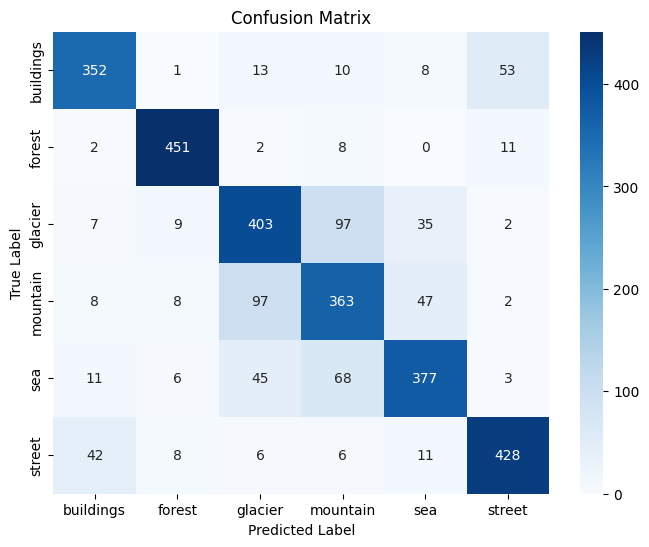

In [15]:
# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred
)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Phân tích số lượng mẫu dự đoán sai

Tìm:
- Các ảnh bị phân loại sai
- Tổng số lỗi của mô hình

In [16]:

# =========================================================
# MISCLASSIFIED SAMPLES
# =========================================================

misclassified_idx = np.where(
    y_test != y_pred
)[0]

print("\nMisclassified samples:",
      len(misclassified_idx))


Misclassified samples: 626


## Trực quan hóa các mẫu dự đoán sai

Hiển thị:
- Ảnh gốc
- Nhãn thật
- Nhãn dự đoán

Giúp phân tích:
- Các lớp dễ nhầm lẫn
- Nguyên nhân lỗi của mô hình

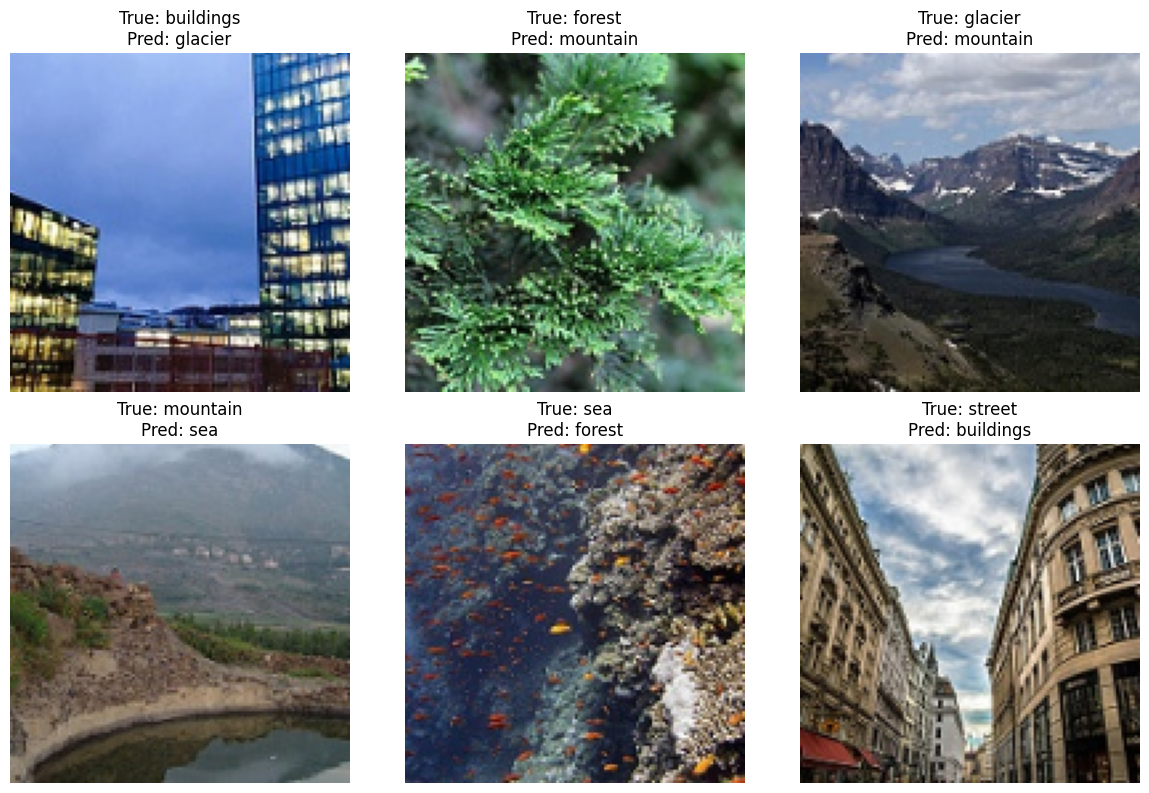

In [21]:
# =========================================================
# SHOW WRONG PREDICTIONS FOR ALL CLASSES
# =========================================================

selected_idx = []

# duyệt từng class
for class_id in range(len(classes)):

    # tìm các ảnh:
    # true label = class_id
    # nhưng predict sai
    class_misclassified = np.where(
        (y_test == class_id) &
        (y_pred != class_id)
    )[0]

    # nếu class này có predict sai
    if len(class_misclassified) > 0:

        # lấy 1 sample đầu tiên
        selected_idx.append(
            class_misclassified[0]
        )

# =========================================================
# PLOT
# =========================================================

num_show = len(selected_idx)

plt.figure(figsize=(12, 8))

for i, idx in enumerate(selected_idx):

    plt.subplot(2, 3, i+1)

    plt.imshow(X_test[idx])

    true_label = classes[y_test[idx]]
    pred_label = classes[y_pred[idx]]

    plt.title(
        f"True: {true_label}\n"
        f"Pred: {pred_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

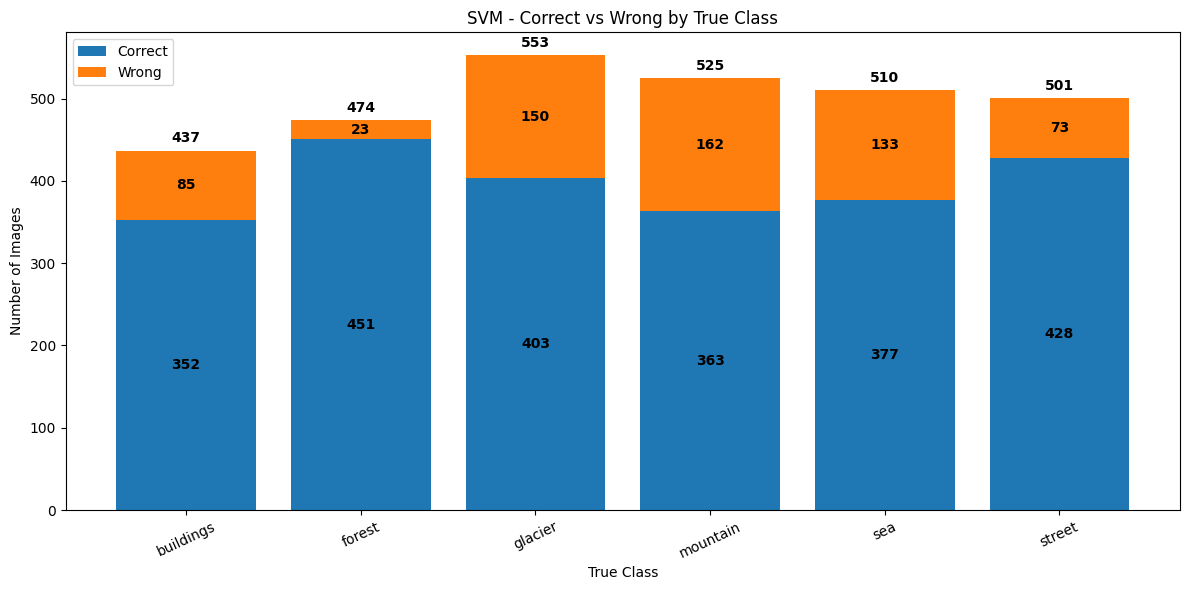

In [ ]:

# =========================================================
# Count correct / wrong prediction by class
# =========================================================

correct_counts = []
wrong_counts = []

for i, class_name in enumerate(classes):
    # samples of this class
    idx = np.where(y_test == i)[0]
    # correct
    correct = np.sum(
        y_pred[idx] == y_test[idx]
    )
    # wrong
    wrong = np.sum(
        y_pred[idx] != y_test[idx]
    )
    correct_counts.append(correct)
    wrong_counts.append(wrong)
# total samples
totals = [
    c + w
    for c, w in zip(correct_counts, wrong_counts)
]

# =========================================================
# Plot
# =========================================================
x = np.arange(len(classes))
plt.figure(figsize=(12,6))
# correct bar
plt.bar(
    x,
    correct_counts,
    label='Correct'
)
# wrong stacked bar
plt.bar(
    x,
    wrong_counts,
    bottom=correct_counts,
    label='Wrong'
)

# =========================================================
# Labels inside bars
# =========================================================
for i in range(len(classes)):
    # correct count
    plt.text(
        x[i],
        correct_counts[i] / 2,
        str(correct_counts[i]),
        ha='center',
        va='center',
        fontweight='bold'
    )
    # wrong count
    plt.text(
        x[i],
        correct_counts[i] + wrong_counts[i] / 2,
        str(wrong_counts[i]),
        ha='center',
        va='center',
        fontweight='bold'
    )
    # total
    plt.text(
        x[i],
        totals[i] + 10,
        str(totals[i]),
        ha='center',
        fontweight='bold'
    )

# =========================================================
# Formatting
# =========================================================
plt.xticks(
    x,
    classes,
    rotation=25
)
plt.ylabel("Number of Images")
plt.xlabel("True Class")
plt.title(
    "SVM - Correct vs Wrong by True Class"
)
plt.legend()
plt.tight_layout()
plt.show()